In [7]:
import pandas as pd  # Import pandas library for data analysis

# Load dataset from your system using full file path
df = pd.read_csv(r"C:/Users/vivek/Desktop/VIVEK LANGUAGE PROJECT/Data_Sets/train.csv")

# Preview first 5 rows to understand structure
print(df.head())  

# Get dataset info (columns, data types, null values)
print(df.info())

# Convert 'Order Date' column to datetime format (day comes first in your data)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Convert 'Ship Date' column to datetime format
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Check missing values in each column
print(df.isnull().sum())  

# Remove duplicate rows to clean data
df = df.drop_duplicates()

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08-11-2017  11-11-2017    Second Class    CG-12520   
1       2  CA-2017-152156  08-11-2017  11-11-2017    Second Class    CG-12520   
2       3  CA-2017-138688  12-06-2017  16-06-2017    Second Class    DV-13045   
3       4  US-2016-108966  11-10-2016  18-10-2016  Standard Class    SO-20335   
4       5  US-2016-108966  11-10-2016  18-10-2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [9]:
# Calculate total sales by summing all values in 'Sales' column
total_sales = df['Sales'].sum()

# Print the result in a readable format
print("Total Sales:", total_sales)

Total Sales: 2261536.7827


In [20]:
# Group data by 'Product Name' and calculate total sales for each product
top_product = df.groupby('Product Name')['Sales'].sum()  

# Sort products by sales in descending order (highest sales first)
top_product = top_product.sort_values(ascending=False)  

# Select top 10 products based on sales
top_product = top_product.head(10)  

# Print the result
print(top_product)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [21]:
# Show region-wise sales in descending order (highest first)
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# Print formatted output
print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [23]:
# Sort months in correct order (just to be safe)
monthly_sales = monthly_sales.sort_index()

# Print result
print(monthly_sales)

Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


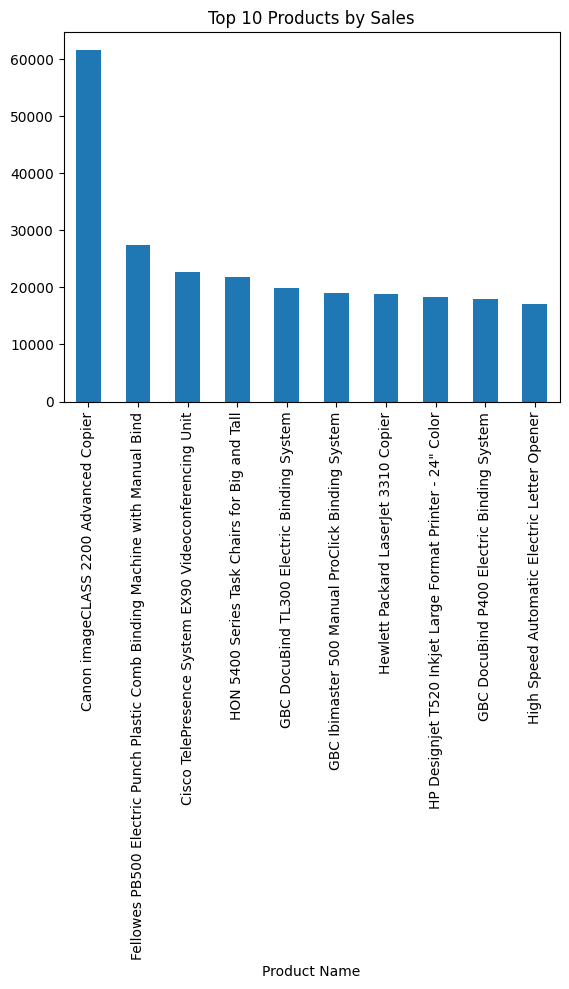

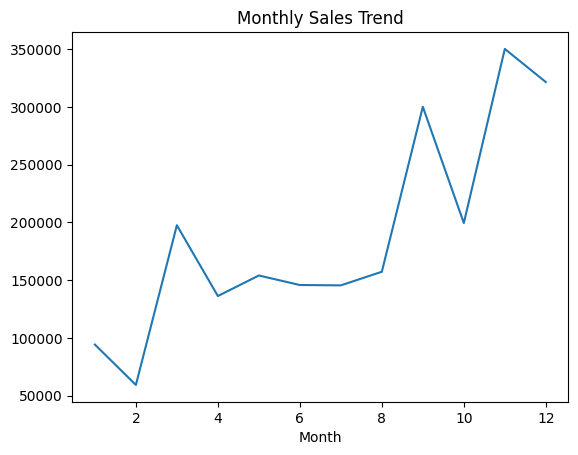

In [28]:
import matplotlib.pyplot as plt   # Library for plotting graphs
import seaborn as sns            # Advanced visualization library

# -------- Top Products Chart --------

# Plot bar chart for top 10 products based on sales
top_product.plot(kind='bar')

# Add title to the chart
plt.title("Top 10 Products by Sales")

# Display the chart
plt.show()

# -------- Monthly Sales Trend --------

# Create line plot for monthly sales trend
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)

# Add title to the chart
plt.title("Monthly Sales Trend")

# Display the chart
plt.show()